# Eksamen 2026 — MAMO2200 Avansert Modellering
## Tema: Midtpunktregelen og Legendre-approksimasjon

---

### Prosjektoppsett og reproduserbarhet

| Verktøy | Formål |
|---------|--------|
| **[uv](https://docs.astral.sh/uv/)** | Pakkehåndtering og isolert virtuelt miljø. `uv sync` installerer alle avhengigheter fra `pyproject.toml` i nøyaktig samme versjoner — uavhengig av maskinen som kjører koden. |
| **[GitHub](https://github.com/)** | Versjonskontroll og revisjonsspor. Innfrielse av krav i **EU AI Act** (Forordning (EU) 2024/1689, art. 12–13) om sporbarhet og dokumentasjon for AI-systemer. |
| **[Dependabot](https://docs.github.com/en/code-security/dependabot)** | Holder `pyproject.toml` oppdatert ved å automatisk åpne pull requests når nyere versjoner av pakker er tilgjengelig. |

> **For å sette opp miljøet:** kjør `.\setup.ps1` (Windows) eller `./setup.sh` (Linux/Mac) én gang, deretter `Ctrl+Shift+P → "Reload Window"` i VS Code.

## Oppgaven

Gitt funksjonen

$$f(x) = e^{-x^2}\left(x^2 - \frac{1}{2}x + \frac{1}{2}\right)$$

på intervallet $[-1, 1]$. Estimer integralene

$$I_k = \int_{-1}^{1} x^k f(x)\,dx, \quad k = 0,1,2,3,4$$

ved å bruke **midtpunktregelen** med $n - 1 = 100$ delintervaller.

Bruk estimatene til å beregne koeffisientene $a_0, a_1, \ldots, a_4$ i Legendre-approksimasjonen

$$p_4(x) = \sum_{k=0}^{4} a_k P_k(x).$$

Plott grafen til $p_4(x)$ sammen med grafen til $f(x)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Del 1 — Midtpunktregelen

Vi deler intervallet $[a, b]$ inn i $n - 1$ like store delintervaller med bredde

$$h = \frac{b - a}{n - 1}.$$

Midtpunktregelen bruker midtpunktet $m_i = x_i + \tfrac{h}{2}$ i hvert delintervall og gir tilnærmingen

$$\int_a^b f(x)\,dx \approx \sum_{i=0}^{n-2} h\,f(m_i).$$

Feilen er av orden $O(h^2)$; med 100 delintervaller og $h = 0.02$ er feilen liten.

Vi implementerer midtpunktregelen nedenfor og definerer $f(x)$.

In [2]:
def midpoint(f, a, b, n):
    """Regn ut integralet av ``f`` ved hjelp av midtpunktregelen.

    Parameters
    ----------
    f : callable
        Funksjonen vi ønsker å integrere.
    a : float
        Nedre grense for integrasjonen.
    b : float
        Øvre grense for integrasjonen.
    n : int
        Antall noder (grensepunkter), slik at antall delintervaller er n-1.

    Returns
    -------
    float
        En numerisk tilnærming til integralet av ``f`` fra ``a`` til ``b``.
    """
    h = (b - a) / (n - 1)
    ms = np.arange(a + 0.5*h, b, h)   # n-1 midtpunkter
    fs = f(ms)
    return h * np.sum(fs)


def f(x):
    return np.exp(-x**2) * (x**2 - 0.5*x + 0.5)

In [3]:
# n-1 = 100 delintervaller  =>  n = 101
n = 101
a_int, b_int = -1.0, 1.0

# Estimer I_k = integral fra -1 til 1 av x^k * f(x) dx,  k = 0,1,2,3,4
I = np.zeros(5)
for k in range(5):
    I[k] = midpoint(lambda x, k=k: x**k * f(x), a_int, b_int, n)

print('Estimerte integraler I_k = integral av x^k * f(x) dx:')
for k in range(5):
    print(f'  I_{k} = {I[k]:.10f}')

Estimerte integraler I_k = integral av x^k * f(x) dx:
  I_0 = 1.1257810880
  I_1 = -0.1894723461
  I_2 = 0.3899854142
  I_3 = -0.1002565341
  I_4 = 0.2336720302


## Del 2 — Legendre-koeffisienter

Legendre-polynomene $P_k(x)$ er ortogonale på $[-1, 1]$:

$$\langle P_j, P_k \rangle = \int_{-1}^1 P_j(x) P_k(x)\,dx = \frac{2}{2k+1}\,\delta_{jk}.$$

Koeffisienten i utviklingen $f(x) = \sum_k a_k P_k(x)$ er

$$a_k = \frac{2k+1}{2} \int_{-1}^1 f(x)\,P_k(x)\,dx.$$

De eksplisitte uttrykkene for de første fem Legendre-polynomene er:

| $k$ | $P_k(x)$ |
|-----|----------|
| 0 | $1$ |
| 1 | $x$ |
| 2 | $\tfrac{1}{2}(3x^2 - 1)$ |
| 3 | $\tfrac{1}{2}(5x^3 - 3x)$ |
| 4 | $\tfrac{1}{8}(35x^4 - 30x^2 + 3)$ |

Integralet $\int_{-1}^1 f(x) P_k(x)\,dx$ er en **lineærkombinasjon av $I_0, \ldots, I_k$** vi allerede har estimert:

$$a_0 = \tfrac{1}{2} I_0$$

$$a_1 = \tfrac{3}{2} I_1$$

$$a_2 = \tfrac{5}{4}(3 I_2 - I_0)$$

$$a_3 = \tfrac{7}{4}(5 I_3 - 3 I_1)$$

$$a_4 = \tfrac{9}{16}(35 I_4 - 30 I_2 + 3 I_0)$$

In [4]:
# Beregn a_k fra I_k ved å sette inn uttrykkene for P_k(x)
a = np.zeros(5)
a[0] = 1/2  * I[0]
a[1] = 3/2  * I[1]
a[2] = 5/4  * (3*I[2] - I[0])
a[3] = 7/4  * (5*I[3] - 3*I[1])
a[4] = 9/16 * (35*I[4] - 30*I[2] + 3*I[0])

print('Legendre-koeffisienter:')
for k in range(5):
    print(f'  a_{k} = {a[k]:.10f}')

Legendre-koeffisienter:
  a_0 = 0.5628905440
  a_1 = -0.2842085192
  a_2 = 0.0552189434
  a_3 = 0.1174851440
  a_4 = -0.0808301855


## Del 3 — Plotting

Vi setter opp $p_4(x) = \sum_{k=0}^4 a_k P_k(x)$ og plotter den mot $f(x)$.

Legendre-approksimasjonen minimerer $L^2$-feilen $\|f - p_4\|_2^2 = \int_{-1}^1 (f(x) - p_4(x))^2\,dx$ globalt på intervallet, i motsetning til Taylor-polynomer som minimerer feilen lokalt rundt ett punkt.

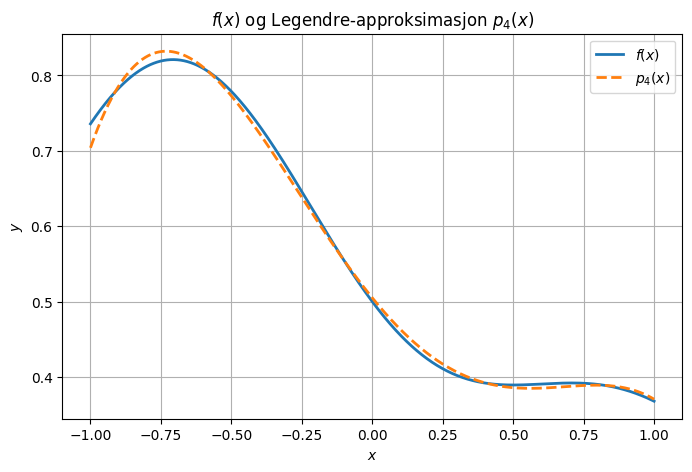

Estimert L²-feil  ||f - p₄||₂ ≈ 1.01e-02


In [5]:
xs = np.linspace(-1, 1, 1001)

# Legendre-polynomene evaluert i xs
P_0 = np.ones(xs.size)
P_1 = xs
P_2 = 0.5 * (3*xs**2 - 1)
P_3 = 0.5 * (5*xs**3 - 3*xs)
P_4 = (35*xs**4 - 30*xs**2 + 3) / 8

# Legendre-approksimasjon p_4(x)
p4 = a[0]*P_0 + a[1]*P_1 + a[2]*P_2 + a[3]*P_3 + a[4]*P_4

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, f(xs), label='$f(x)$', linewidth=2)
ax.plot(xs, p4,   label='$p_4(x)$', linestyle='--', linewidth=2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('$f(x)$ og Legendre-approksimasjon $p_4(x)$')
ax.legend()
ax.grid()
plt.show()

# L2-feil
h_plot = xs[1] - xs[0]
l2_error = np.sqrt(h_plot * np.sum((f(xs) - p4)**2))
print(f'Estimert L²-feil  ||f - p₄||₂ ≈ {l2_error:.2e}')

## Alternative integrasjonsmetoder

Midtpunktregelen kan byttes ut med en hvilken som helst annen metode for å beregne $I_k = \int_{-1}^{1} x^k f(x)\,dx$.  
Tabellen nedenfor viser aktuelle alternativer med funksjonskall, feilorden og krav.

| Metode | Funksjonskall | Feilorden | Krav / merknad |
|---|---|---|---|
| **Midtpunktregelen** (vår) | `midpoint(f, a, b, n)` | $O(h^2)$ | `h = (b−a)/(n−1)`, bruker `n−1` midtpunkter |
| **Trapesregelen** | `np.trapezoid(f(xs), xs)` | $O(h^2)$ | Krever NumPy ≥ 2.0 (`np.trapz` for eldre) |
| **Simpsons regel** | `scipy.integrate.simpson(f(xs), x=xs)` | $O(h^4)$ | Antall punkter bør være odde |
| **Adaptiv Gauss-Kronrod** | `scipy.integrate.quad(f, a, b)[0]` | ~maskinpresisjon | Returnerer `(verdi, feilestim.)` – ingen $n$ |
| **Gauss-Legendre** (fast) | `scipy.integrate.fixed_quad(f, a, b, n=5)[0]` | Eksakt for polynomer av grad $\leq 2n-1$ | God for polynomaktige integrander |
| **Clenshaw-Curtis** | `scipy.integrate.quad(f, a, b, limit=n)[0]` | ~maskinpresisjon | Adaptiv; `limit` styrer max antall evalueringer |

Funksjonen `integrate` nedenfor samler alle metodene og gjør det enkelt å bytte.

Valgt metode: trapes
Estimerte integraler I_k = integral av x^k * f(x) dx:
  I_0 = 1.1257442982
  I_1 = -0.1894723455
  I_2 = 0.3900589956
  I_3 = -0.1002933251
  I_4 = 0.2338559791

Estimert L2-feil  ||f - p4||_2 approx 1.01e-02


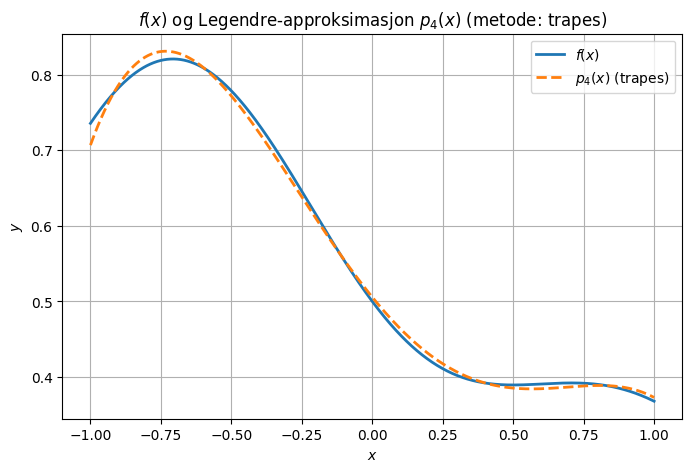

In [ ]:
import numpy as np
from scipy.integrate import simpson, quad, fixed_quad


def integrate(f, a, b, n=101, metode="midtpunkt"):
    """
    Beregn integralet av f over [a, b].

    Parameters
    ----------
    f      : callable  -- funksjon av en variabel
    a, b   : float     -- integrasjonsgrenser
    n      : int       -- antall noder (brukes av midtpunkt, trapes, simpson)
    metode : str       -- en av:
               "midtpunkt"      -- midtpunktregelen (var opprinnelige)
               "trapes"         -- trapesregelen (np.trapezoid)
               "simpson"        -- Simpsons regel (scipy.integrate.simpson)
               "adaptiv"        -- adaptiv Gauss-Kronrod (scipy.integrate.quad)
               "gauss_legendre" -- fast Gauss-Legendre, n angir antall noder

    Returns
    -------
    float -- approksimert integralverdi
    """
    if metode == "midtpunkt":
        h = (b - a) / (n - 1)
        ms = np.arange(a + 0.5 * h, b, h)
        return h * np.sum(f(ms))

    elif metode == "trapes":
        xs = np.linspace(a, b, n)
        return np.trapezoid(f(xs), xs)

    elif metode == "simpson":
        n_odd = n if n % 2 == 1 else n + 1
        xs = np.linspace(a, b, n_odd)
        return simpson(f(xs), x=xs)

    elif metode == "adaptiv":
        verdi, _ = quad(f, a, b)
        return verdi

    elif metode == "gauss_legendre":
        verdi, _ = fixed_quad(f, a, b, n=n)
        return verdi

    else:
        raise ValueError(
            f"Ukjent metode: {metode!r}. "
            "Velg blant: 'midtpunkt', 'trapes', 'simpson', 'adaptiv', 'gauss_legendre'"
        )


# --- Bytt metode og antall noder her ---
METODE = "midtpunkt"   # proev: "trapes", "simpson", "adaptiv", "gauss_legendre"
N = 101                # antall noder => N-1 delintervaller (brukes ikke av "adaptiv")

# Beregn I_k med valgt metode
print(f"Valgt metode: {METODE},  N = {N}  ({N-1} delintervaller)")
print("Estimerte integraler I_k = integral av x^k * f(x) dx:")
I_alt = np.zeros(5)
for k in range(5):
    I_alt[k] = integrate(lambda x, k=k: x**k * f(x), a_int, b_int, n=N, metode=METODE)
    print(f"  I_{k} = {I_alt[k]:.10f}")

# Beregn Legendre-koeffisienter fra de nye I_k-verdiene
a_alt = np.zeros(5)
a_alt[0] = 1/2  * I_alt[0]
a_alt[1] = 3/2  * I_alt[1]
a_alt[2] = 5/4  * (3*I_alt[2] - I_alt[0])
a_alt[3] = 7/4  * (5*I_alt[3] - 3*I_alt[1])
a_alt[4] = 9/16 * (35*I_alt[4] - 30*I_alt[2] + 3*I_alt[0])

# Beregn p_4(x) med de nye koeffisientene
xs_alt = np.linspace(-1, 1, 1001)
P_0_alt = np.ones(xs_alt.size)
P_1_alt = xs_alt
P_2_alt = 0.5 * (3*xs_alt**2 - 1)
P_3_alt = 0.5 * (5*xs_alt**3 - 3*xs_alt)
P_4_alt = (35*xs_alt**4 - 30*xs_alt**2 + 3) / 8
p4_alt = (a_alt[0]*P_0_alt + a_alt[1]*P_1_alt + a_alt[2]*P_2_alt
          + a_alt[3]*P_3_alt + a_alt[4]*P_4_alt)

# L2-feil
h_alt = xs_alt[1] - xs_alt[0]
l2_alt = np.sqrt(h_alt * np.sum((f(xs_alt) - p4_alt)**2))
print(f"\nEstimert L2-feil  ||f - p4||_2 approx {l2_alt:.2e}")

# Plott
fig_alt, ax_alt = plt.subplots(figsize=(8, 5))
ax_alt.plot(xs_alt, f(xs_alt), label='$f(x)$', linewidth=2)
ax_alt.plot(xs_alt, p4_alt, label=f'$p_4(x)$ ({METODE}, N={N})', linestyle='--', linewidth=2)
ax_alt.set_xlabel('$x$')
ax_alt.set_ylabel('$y$')
ax_alt.set_title(f'$f(x)$ og Legendre-approksimasjon $p_4(x)$ (metode: {METODE}, N={N})')
ax_alt.legend()
ax_alt.grid()
plt.show()
